# ***Deep Q Network***

DQN - Most popular deep reinforcement learning algorithms. It is the starting point where reinforcement learning and deep learning meet each other.

Researchers at Google's DeepMind developed DQN algorithm to play Atari games in 2013.

Breakout in Atari Games - Goal is to destroy all bricks by hitting with a ball. States are represented using a sequence of 4 screen pixels 84x84 of 256 gray levels.

A single screen of the breakout game is shown below.

In [1]:
from IPython.display import Image, display

# For a public URL
display(Image(url="https://ale.farama.org/_images/breakout.gif"))

Using the right controller, one players attempts to destroy the two
walls using five balls.  Or, a player can win by scoring the maximum
number of points, 864.

There are six rows of bricks.  The color of a brick determines the
points you score when you hit it with your ball.


Red - 7 points         Orange - 7 points        Yellow - 4 points
Green - 4 points       Aqua - 1 point           Blue - 1 point

Now, let's calculate the size of the state space for the Breakout game (i.e.,
all possible states that can occur in this game):

256^(4×84×84) ≈ 10^(65000).

To understand how large this number is, I'd like to tell you that the number of
atoms in our universe is 1081! Yes, the number of different states of an
elementary arcade game exceeds the number of atoms in our universe. And
this applies to all complex environments. Of course, the classical Qlearning
approach is not suitable for solving such problems. It is physically
impossible to iterate the game so many times to determine the effective
action for each state. But the Q-learning approach itself has already proven
its effectiveness. We just need a few modifications to apply it to tasks with a
large space state.

**The primary assumption for environments with a large number of states is:
The agent must act in the same way in close states in most cases or With
minor changes in the state, the agent's actions change slightly.**

Take a look at the following images.

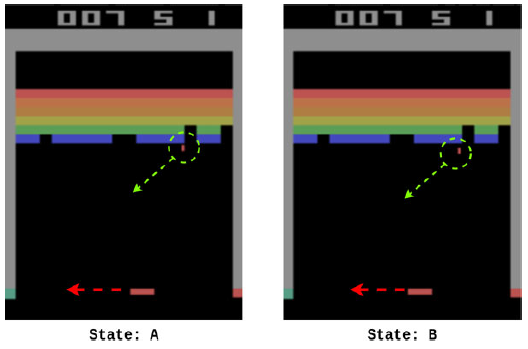



**Experience Distribution**

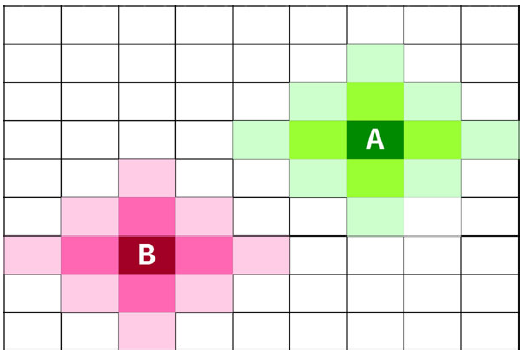

The neural network models the Q(s, a) function as follows: it takes input s and returns a vector a (one-dimensional tensor), where each value of this tensor represents the value of corresponding ai action for state s, as shown in the following figure.

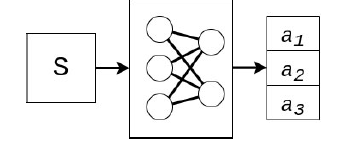

***Convergence of temporal difference and DQN training loss function***

Consider the
rule again for updating the value of Q(s, a) function:

Q(s, a) ← Q(s, a) + α temporal_difference

***There is a law: If temporal_difference converges to zero then Q(s, a)- function is being successfully trained.*** It may be intuitively clear that the longer the exploration runs, the less new information the temporal_difference value provides.

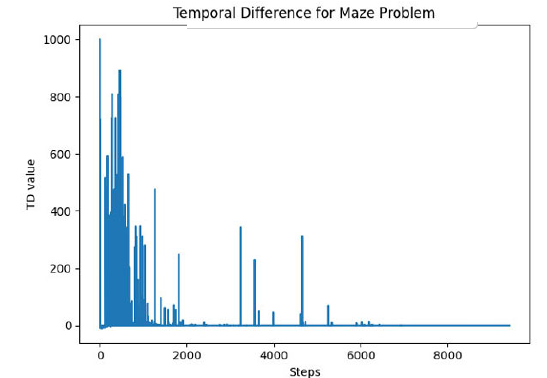

**Replay Buffer**

In classical Q-learning, Q(s, a) is updated based on the values s, a, r, and s',
where:

s: Existing state

a: Action taken

r: Reward after action a in state s

s': Next state after action a in state s

In DQN, many (s, a, r, s') samples are used for training. These samples are
collected during exploration in a special buffer called **Replay Buffer**.

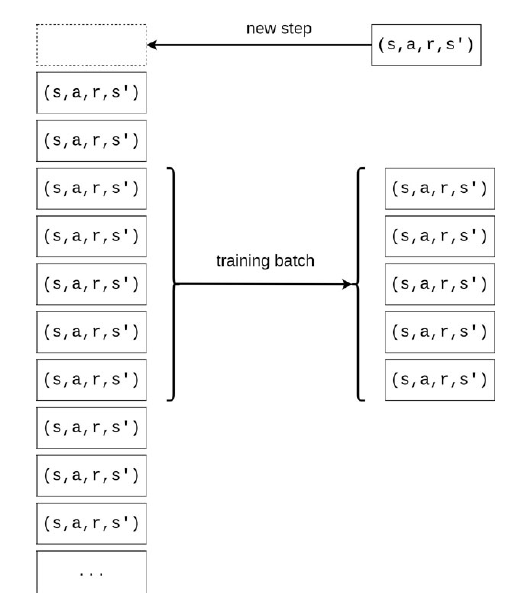

Here is the Python implementation of ReplayBuffer data structure.

The ReplayBuffer class is initialized with two variables:

buffer_size: Maximum buffer size

batch_size: Size of training batch

In [2]:
import numpy as np
import random
from collections import namedtuple, deque

class ReplayBuffer:
  def __init__(self, buffer_size, batch_size):
    self.memory = deque(maxlen = buffer_size)
    self.batch_size = batch_size
    self.experience = namedtuple("Experience", field_names =
["state", "action", "reward", "next_state", "done"])

  # Adding new experience sample
  def add(self, state, action, reward, next_state, done):
    e = self.experience(state, action, reward, next_state, done)
    self.memory.append(e)

  # Randomly sampling a batch of experiences from memory
  def sample(self, batch_size = None):
    if batch_size is None:
      batch_size = self.batch_size
    experiences = random.sample(self.memory, k = batch_size)
    states = np.vstack([e.state for e in experiences if e is not None])
    actions = np.vstack([e.action for e in experiences if e is not None])
    rewards = np.vstack([e.reward for e in experiences if e is not None])
    next_states = np.vstack([e.next_state for e in experiences if e is not None])
    dones = np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)
    return states, actions, rewards, next_states, dones

  def __len__(self):
    return len(self.memory)

As we can see, ReplayBuffer is a pretty simple data structure that just
collects experience samples. ReplayBuffer is a primary component of
DQN model.

# **DQN Implementation**

Tensor Method - gather

The gather method collects values from the input tensor according to the passed indices.


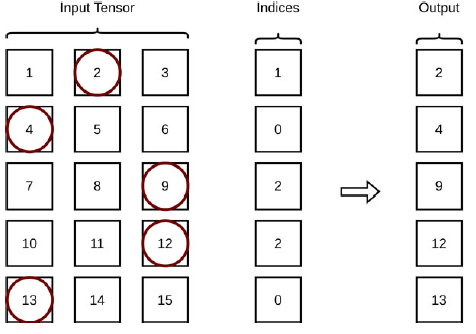

In [3]:
import tensorflow as tf

def tf_2d_gather(params, idx):
  idx = tf.stack([tf.range(tf.shape(idx)[0]), idx[:, 0]], axis= -1)
  out = tf.gather_nd(params, idx)
  out = tf.expand_dims(out, axis = 1)
  return out

params = tf.constant([[1, 2], [3, 4]])
idx = tf.constant([[0], [1]])
out = tf_2d_gather(params, idx)
print(out.numpy())

[[1]
 [4]]


The Neural Network is the computational core of DQN model. We will call it QNet. DQN can use various QNet architectures. QNet architecture of DQN model depends on the environment with which the agent interacts. Usually, fully connected or convolution neural networks are used for DQN model. This chapter will focus on a fully connected neural network with three linear layers as QNet implementation.


In [4]:
import tensorflow as tf
from keras.layers import Dense

class TfQNet(tf.keras.Model):

  def __init__(self, state_size, action_size, fc1_units = 64,fc2_units = 64):
    super(TfQNet, self).__init__()
    self.fc1 = Dense(units = fc1_units, activation = tf.nn.relu)
    self.fc2 = Dense(units = fc2_units, activation = tf.nn.relu)
    self.fc3 = Dense(units = action_size)

  def call(self, state, **kwargs):
    x = self.fc1(state)
    x = self.fc2(x)
    return self.fc3(x)

**Generic Logic of Agent**

DQN Agent is initialized using the following parameters:

state_size: The size of environment state

action_size: The size of action space

degp_epsilon: Initial epsilon value for decayed epsilon-greedy policy

degp_decay_rate: Decay rate for decayed epsilon greedy policy

degp_min_epsilon: Minimal epsilon value

learn_period: How often QNet is trained


In [5]:
class BaseDqnAgent:

  def __init__(
self,
state_size,
action_size,
degp_epsilon = 1,
degp_decay_rate = .9,
degp_min_epsilon = .1,
train_batch_size = 64,
replay_buffer_size = 100_000,
gamma = 0.99,
learning_rate = 5e-4,
learn_period = 1
):
    self.state_size = state_size
    self.action_size = action_size
    self.degp_epsilon = self.degp_initial_epsilon = degp_epsilon
    self.degp_decay_rate = degp_decay_rate
    self.degp_min_epsilon = degp_min_epsilon

# Q-Network initialized in init_q_net method
    self.q_net = None
    self.optimizer = None
    self.loss = None
    self.learn_period = learn_period
    self.init_q_net(state_size, action_size, learning_rate)

# Replay memory
    self.memory = ReplayBuffer(replay_buffer_size,train_batch_size)
# Initialize time step (for updating every UPDATE_EVERY steps)
    self.training_steps_count = 0
    self.train_batch_size = train_batch_size
    self.replay_buffer_size = replay_buffer_size
    self.gamma = gamma

  # init_q_net is a framework-specific method that initializes QNet, its optimizer and loss function
  def init_q_net(self, state_size, action_size, learning_rate):
   ...

  # Before each episode, epsilon is decreased according to decaying policy
  def before_episode(self):
    self.degp_epsilon *= self.degp_decay_rate
    self.degp_epsilon = max(self.degp_epsilon,self.degp_min_epsilon)

  # The step method is executed after each action taken by the agent. This method saves (s, a, r, s') sample to Replay Buffer and trains QNet
  def step(self, state, action, reward, next_state, done):
    self.memory.add(state, action, reward, next_state, done)
    self.training_steps_count += 1
    # QNet is retrained according to the self.learn_period value
    if self.training_steps_count % self.learn_period == 0:
      if len(self.memory) > self.train_batch_size:
        self.learn()

  # Agent takes actions according to epsilon-greedy policy. If Agent runs in train mode and random value is lower than self.degp_epsilon, then
  # random action is taken. Otherwise, Agent selects action according to greedy policy
  def act(self, state, mode = 'train'):
    r = random.random()
    random_action = mode == 'train' and r < self.degp_epsilon
    if random_action:
      # Random Policy
      action = random.choice(np.arange(self.action_size))
    else:
     action = self.greedy_act(state)
    return action

  # The greedy_act is a framework-specific method that returns action according to greedy policy for given state:
  def greedy_act(self, state):
    return None

  # The learn method is a framework-specific method that trains QNet
  def learn(self):
    ...

  # The save method is a framework-specific method that saves QNet to path
  def save(self, path):
    ...

  # The load is a framework-specific method that loads QNet from path
  def load(self, path):
    ...

In [6]:
class DqnTfAgent(BaseDqnAgent):
  def __init__(self, *args, **kwargs):
    super(DqnTfAgent, self).__init__(*args, **kwargs)

  # Initializing QNet, optimizer, and loss function
  def init_q_net(self, state_size, action_size, learning_rate):
    self.q_net = TfQNet(state_size, action_size)
    self.q_net.build(input_shape = (1, state_size))
    self.optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
    self.loss = tf.keras.losses.MeanSquaredError()

  def greedy_act(self, state):
    state = tf.constant(state, dtype = tf.float64)
    state = tf.expand_dims(state, axis = 0)
    action_values = self.q_net(state)
    return np.argmax(action_values.numpy())

  def learn(self):
    # Agent receives history samples from ReplayBuffer
    samples = self.memory.batch()
    s, a, r, s_next, dones = samples
    # Extracting QNet variables for optimization
    variables = self.q_net.variables
    # minimize temporal difference
    # Calculating V(s') value
    v_s_next = tf.expand_dims(tf.reduce_max(self.q_net(s_next), axis = 1), axis = 1)
    with tf.GradientTape() as tape:
      # Calculating Q(s, a) value using the gather method
      q_sa_pure = self.q_net(s)
      q_sa = tf_2d_gather(q_sa_pure, a)
      # Calculating Temporal Difference
      td = r + (self.gamma * v_s_next * (1 - dones)) - q_sa
      # Error value indicates how far Temporal Difference is from zero
      error = self.loss(td, tf.zeros(td.shape))
    # Optimizing QNet weights
    gradient = tape.gradient(error, variables)
    self.optimizer.apply_gradients(zip(gradient, variables))

  # Additional save and load methods
  def save(self, path):
    self.q_net.save(path)

  def load(self, path):
    self.q_net = tf.keras.models.load_model(path)

We have created a DQN model.

# **Lunar Landing using DQN Agent**

Gym framework has a special environment called LunarLander-v3. The agent's goal in this environment is to land the spacecraft on the dedicated platform on the moon. Lunar lander figure is shown here.

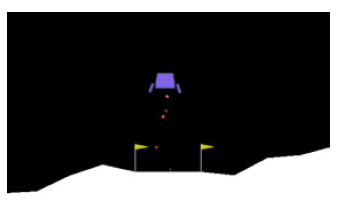

**State of the LunarLander-v2 environment is represented by eight values:**

s[0]: This is the horizontal coordinate (float)

s[1]: This is the vertical coordinate (float)

s[2]: This is the horizontal speed (float)

s[3]: This is the vertical speed (float)

s[4]: This is the angle (float)

s[5]: This is the angular speed (float)

s[6]: 1 if first leg has contact, else 0 (boolean)

s[7]: 1 if second leg has contact, else 0 (boolean)

**Four discrete actions are available for the agent:**

do nothing: Lander moves down

fire left orientation engine: Lander moves right

fire main engine: Lander moves up

fire right orientation engine: Lander moves left


Success: Moving toward the landing pad with zero speed earns 100–140 points;
coming to rest yields +100 points.

Contact: +10 points for each leg making ground contact.

Penalties: -0.3 points per frame for firing the main engine; -100 points for crashing.

Goal: Achieving an average score of 200 points over 100 consecutive episodes is considered "solved"

**Environment**

Fuel is infinite. A landing pad always has coordinates (0, 0). Lander
coordinates are the first two numbers in the state vector (s[0], s[1]).

**DQN Application**

Agent balances the lander straight to the pad. So, let's train the
DQN model to do the same!

In [7]:
!pip install Cmake

   ---------------------------------------- 0.0/38.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.9 MB ? eta -:--:--
    --------------------------------------- 0.5/38.9 MB 2.8 MB/s eta 0:00:14
   - -------------------------------------- 1.0/38.9 MB 1.9 MB/s eta 0:00:21
   - -------------------------------------- 1.3/38.9 MB 1.9 MB/s eta 0:00:21
   - -------------------------------------- 1.8/38.9 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.1/38.9 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.4/38.9 MB 1.8 MB/s eta 0:00:21
   -- ------------------------------------- 2.9/38.9 MB 1.8 MB/s eta 0:00:20
   --- ------------------------------------ 3.4/38.9 MB 1.8 MB/s eta 0:00:20
   --- ------------------------------------ 3.7/38.9 MB 1.9 MB/s eta 0:00:19
   ---- ----------------------------------- 4.2/38.9 MB 1.9 MB/s eta 0:00:19
   ---- ----------------------------------- 4.7/38.9 MB 1.9 MB/s eta 0:00:18
   ----- ----

In [8]:
!apt-get install swig

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


In [9]:
!pip install box2d-py==2.3.8

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build box2d-py


  error: subprocess-exited-with-error
  
  × Building wheel for box2d-py (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [29 lines of output]
      Using setuptools (version 82.0.1).
      C:\Users\samra\AppData\Local\Temp\pip-build-env-yqulsffm\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\samra\AppData\Local\Temp\pip-build-env-yqulsffm\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: zlib/libpng License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              *

In [10]:
#pip !install Box2D‑2.3.10‑cp38‑cp38‑win_amd64.whl
!pip install gym

     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 721.7/721.7 kB 4.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827741 sha256=92a3b39a01ed21eff187fe5abf136ce1071351e7be229c496ff05e08677f5a39
  Stored in directory: c:\users\samra\appdata\local\pip\cache\wheels\1c\77\9e\9af5470201a0b0543937933ee99ba884cd237d2faefe8f4d37
Successfully built gym

   -------------------- ------------------- 1/2 [gym]
   -------------------- ------------------- 1/2 [gym]
   -------------------- ------------------- 1/2 [gym]
   -------------------- ------------------- 1/2 [gym]
   

In [11]:
import gymnasium as gym
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import base64, io

import numpy as np
from collections import deque, namedtuple

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

env = gym.make('LunarLander-v3')
random.seed(0)
print('State shape: ', env.observation_space.shape)
print('Number of actions: ', env.action_space.n)

class QNetwork(nn.Module):

    def __init__(self, state_size, action_size, seed):
        super(QNetwork, self).__init__()
        self.seed = torch.manual_seed(seed)
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        """Build a network that maps state -> action values."""
        x = self.fc1(state)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.fc3(x)

BUFFER_SIZE = int(1e5)  # replay buffer size
BATCH_SIZE = 64         # minibatch size
GAMMA = 0.99            # discount factor
TAU = 1e-3              # for soft update of target parameters
LR = 5e-4               # learning rate
UPDATE_EVERY = 4        # how often to update the network

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class Agent():

    def __init__(self, state_size, action_size, seed):

        self.state_size = state_size
        self.action_size = action_size
        self.seed = random.seed(seed)

        # Q-Network
        self.qnetwork_local = QNetwork(state_size, action_size, seed).to(device)
        self.qnetwork_target = QNetwork(state_size, action_size, seed).to(device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=LR)

        # Replay memory
        self.memory = ReplayBuffer(action_size, BUFFER_SIZE, BATCH_SIZE, seed)
        # Initialize time step (for updating every UPDATE_EVERY steps)
        self.t_step = 0

    def step(self, state, action, reward, next_state, done):
        # Save experience in replay memory
        self.memory.add(state, action, reward, next_state, done)

        # Learn every UPDATE_EVERY time steps.
        self.t_step = (self.t_step + 1) % UPDATE_EVERY
        if self.t_step == 0:
            # If enough samples are available in memory, get random subset and learn
            if len(self.memory) > BATCH_SIZE:
                experiences = self.memory.sample()
                self.learn(experiences, GAMMA)

    def act(self, state, eps=0.):

        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        self.qnetwork_local.eval()
        with torch.no_grad():
            action_values = self.qnetwork_local(state)
        self.qnetwork_local.train()

        # Epsilon-greedy action selection
        if random.random() > eps:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.action_size))

    def learn(self, experiences, gamma):

        # Obtain random minibatch of tuples from D
        states, actions, rewards, next_states, dones = experiences

        ## Compute and minimize the loss
        ### Extract next maximum estimated value from target network
        q_targets_next = self.qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)
        ### Calculate target value from bellman equation
        q_targets = rewards + gamma * q_targets_next * (1 - dones)
        ### Calculate expected value from local network
        q_expected = self.qnetwork_local(states).gather(1, actions)

        ### Loss calculation (we used Mean squared error)
        loss = F.mse_loss(q_expected, q_targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # ------------------- update target network ------------------- #
        self.soft_update(self.qnetwork_local, self.qnetwork_target, TAU)

    def soft_update(self, local_model, target_model, tau):

        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau*local_param.data + (1.0-tau)*target_param.data)

class ReplayBuffer:

    def __init__(self, action_size, buffer_size, batch_size, seed):

        self.action_size = action_size
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])
        self.seed = random.seed(seed)

    def add(self, state, action, reward, next_state, done):
        """Add a new experience to memory."""
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)

    def sample(self):
        """Randomly sample a batch of experiences from memory."""
        experiences = random.sample(self.memory, k=self.batch_size)

        states = torch.from_numpy(np.vstack([e.state for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).long().to(device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float().to(device)

        return (states, actions, rewards, next_states, dones)

    def __len__(self):
        """Return the current size of internal memory."""
        return len(self.memory)

def dqn(n_episodes=500, max_t=1000, eps_start=1.0, eps_end=0.01, eps_decay=0.995):

  scores = []                        # list containing scores from each episode
  scores_window = deque(maxlen=100)  # last 100 scores
  eps = eps_start                    # initialize epsilon
  for i_episode in range(1, n_episodes+1):
    state, _ = env.reset()
    score = 0
    for t in range(max_t):
        action = agent.act(state, eps)
        next_state, reward, done, truncated,info = env.step(action)
        agent.step(state, action, reward, next_state, done)
        state = next_state
        score += reward
        if done:
            break
    scores_window.append(score)       # save most recent score
    scores.append(score)              # save most recent score
    eps = max(eps_end, eps_decay*eps) # decrease epsilon
    print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)), end="")
    if i_episode % 100 == 0:
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)))
    if np.mean(scores_window)>=200.0:
        print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, np.mean(scores_window)))
        torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
        break
  return scores

agent = Agent(state_size=8, action_size=4, seed=0)
scores = dqn()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


State shape:  (8,)
Number of actions:  4
Episode 100	Average Score: -186.37
Episode 200	Average Score: -120.05
Episode 300	Average Score: -40.898
Episode 400	Average Score: -45.93
Episode 500	Average Score: -3.448


The agent lands the lunar lander successfully in all cases. The
solution we have just constructed confirms the promise of the deep
reinforcement learning approach.

In [12]:
import gymnasium as gym
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import base64, io

import numpy as np
from collections import deque, namedtuple

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

env = gym.make('LunarLander-v3')
random.seed(0)
print('State shape: ', env.observation_space.shape)
print('Number of actions: ', env.action_space.n)

class QNetwork(nn.Module):

    def __init__(self, state_size, action_size, seed):
        super(QNetwork, self).__init__()
        self.seed = torch.manual_seed(seed)
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        """Build a network that maps state -> action values."""
        x = self.fc1(state)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.fc3(x)

BUFFER_SIZE = int(1e5)  # replay buffer size
BATCH_SIZE = 64         # minibatch size
GAMMA = 0.99            # discount factor
TAU = 1e-3              # for soft update of target parameters
LR = 5e-4               # learning rate
UPDATE_EVERY = 4        # how often to update the network

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class Agent():

    def __init__(self, state_size, action_size, seed):

        self.state_size = state_size
        self.action_size = action_size
        self.seed = random.seed(seed)

        # Q-Network
        self.qnetwork_local = QNetwork(state_size, action_size, seed).to(device)
        self.qnetwork_target = QNetwork(state_size, action_size, seed).to(device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=LR)

        # Replay memory
        self.memory = ReplayBuffer(action_size, BUFFER_SIZE, BATCH_SIZE, seed)
        # Initialize time step (for updating every UPDATE_EVERY steps)
        self.t_step = 0

    def step(self, state, action, reward, next_state, done):
        # Save experience in replay memory
        self.memory.add(state, action, reward, next_state, done)

        # Learn every UPDATE_EVERY time steps.
        self.t_step = (self.t_step + 1) % UPDATE_EVERY
        if self.t_step == 0:
            # If enough samples are available in memory, get random subset and learn
            if len(self.memory) > BATCH_SIZE:
                experiences = self.memory.sample()
                self.learn(experiences, GAMMA)

    def act(self, state, eps=0.):

        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        self.qnetwork_local.eval()
        with torch.no_grad():
            action_values = self.qnetwork_local(state)
        self.qnetwork_local.train()

        # Epsilon-greedy action selection
        if random.random() > eps:
            return np.argmax(action_values.cpu().data.numpy())
        else:
            return random.choice(np.arange(self.action_size))

    def learn(self, experiences, gamma):

        # Obtain random minibatch of tuples from D
        states, actions, rewards, next_states, dones = experiences

        # -------- Double DQN -------- #

        # Action selection from local network
        best_actions = self.qnetwork_local(next_states).detach().argmax(1).unsqueeze(1)

        # Action evaluation from target network
        q_targets_next = self.qnetwork_target(next_states).gather(1, best_actions)

        # Bellman target
        q_targets = rewards + (gamma * q_targets_next * (1 - dones))

        # Expected Q values from local network
        q_expected = self.qnetwork_local(states).gather(1, actions)

        ### Loss calculation (we used Mean squared error)
        loss = F.mse_loss(q_expected, q_targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # ------------------- update target network ------------------- #
        self.soft_update(self.qnetwork_local, self.qnetwork_target, TAU)

    def soft_update(self, local_model, target_model, tau):

        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau*local_param.data + (1.0-tau)*target_param.data)

class ReplayBuffer:

    def __init__(self, action_size, buffer_size, batch_size, seed):

        self.action_size = action_size
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])
        self.seed = random.seed(seed)

    def add(self, state, action, reward, next_state, done):
        """Add a new experience to memory."""
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)

    def sample(self):
        """Randomly sample a batch of experiences from memory."""
        experiences = random.sample(self.memory, k=self.batch_size)

        states = torch.from_numpy(np.vstack([e.state for e in experiences if e is not None])).float().to(device)
        actions = torch.from_numpy(np.vstack([e.action for e in experiences if e is not None])).long().to(device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences if e is not None])).float().to(device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences if e is not None])).float().to(device)
        dones = torch.from_numpy(np.vstack([e.done for e in experiences if e is not None]).astype(np.uint8)).float().to(device)

        return (states, actions, rewards, next_states, dones)

    def __len__(self):
        """Return the current size of internal memory."""
        return len(self.memory)

def ddqn(n_episodes=500, max_t=1000, eps_start=1.0, eps_end=0.01, eps_decay=0.995):

  scores = []                        # list containing scores from each episode
  scores_window = deque(maxlen=100)  # last 100 scores
  eps = eps_start                    # initialize epsilon
  for i_episode in range(1, n_episodes+1):
    state,_ = env.reset()
    score = 0
    for t in range(max_t):
        action = agent.act(state, eps)
        next_state, reward, done, truncated,info = env.step(action)
        agent.step(state, action, reward, next_state, done)
        state = next_state
        score += reward
        if done:
            break
    scores_window.append(score)       # save most recent score
    scores.append(score)              # save most recent score
    eps = max(eps_end, eps_decay*eps) # decrease epsilon
    print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)), end="")
    if i_episode % 100 == 0:
        print('\rEpisode {}\tAverage Score: {:.2f}'.format(i_episode, np.mean(scores_window)))
    if np.mean(scores_window)>=200.0:
        print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, np.mean(scores_window)))
        torch.save(agent.qnetwork_local.state_dict(), 'checkpoint.pth')
        break
  return scores

agent = Agent(state_size=8, action_size=4, seed=0)
scores = ddqn()

State shape:  (8,)
Number of actions:  4
Episode 100	Average Score: -172.53
Episode 200	Average Score: -126.57
Episode 300	Average Score: -38.132
Episode 400	Average Score: -19.57
Episode 500	Average Score: 78.806
